In [1]:
from __future__ import annotations

import logging
from dataclasses import dataclass
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import copy
import numpy as np
import torch
import torch.optim as optim
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms
from transformers import AutoModelForSequenceClassification, AutoTokenizer


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
LOGGER = logging.getLogger(__name__)


=== Membership Inference Attack Metrics (CNN / Fashion-MNIST) ===
Baseline (full gradients): accuracy=0.9567, AUC=0.9917, JS=0.5917
IOS (indices only):       accuracy=0.8217, AUC=0.9075, JS=0.3731


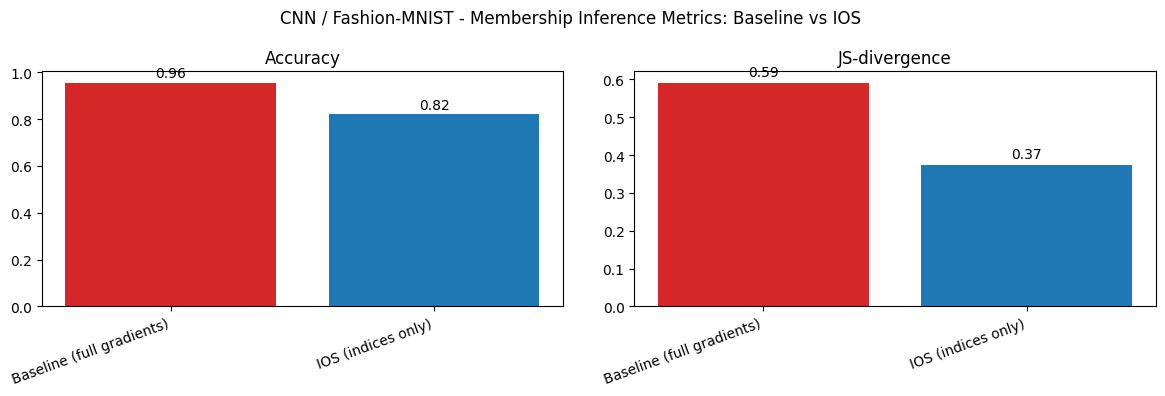

=== Membership Inference Attack Metrics (ResNet18 / CIFAR-10) ===
Baseline (full gradients): accuracy=0.8467, AUC=0.9356, JS=0.4153
IOS (indices only):       accuracy=0.4933, AUC=0.7864, JS=0.2098


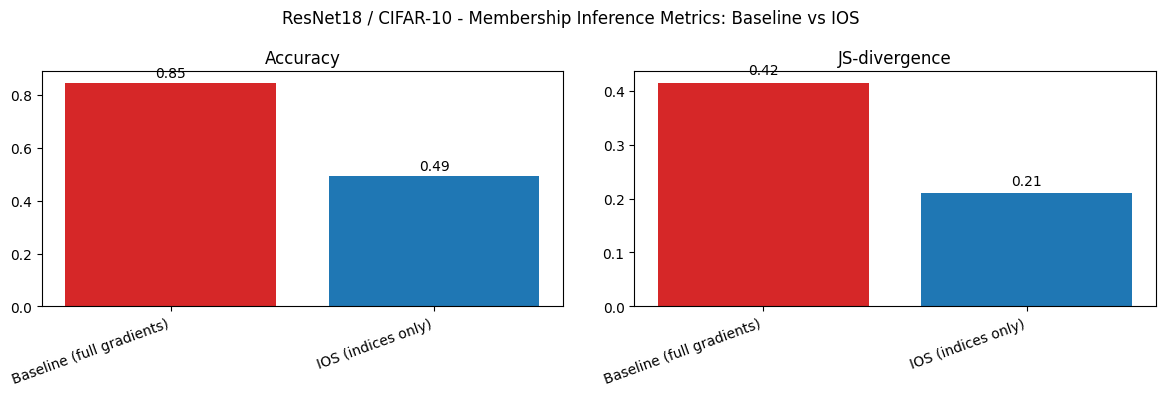

In [ ]:

@dataclass(frozen=True)
class SimulationConfig:
    num_classes: int = 10
    server_samples_per_label: int = 64
    client_samples_per_label: int = 32
    num_rounds: int = 60
    # Fraction of parameters to keep in the top-K IOS index set (0 < top_k_fraction <= 1).
    top_k_fraction: float = 0.05
    random_seed: int = 42
    client_train_epochs: int = 10
    client_train_batch_size: int = 64
    client_learning_rate: float = 1e-3


@dataclass(frozen=True)
class AttackMetrics:
    baseline_accuracy: float
    ios_accuracy: float
    baseline_auc: float
    ios_auc: float
    baseline_js: float
    ios_js: float


def top_k_indices(values: torch.Tensor, fraction: float) -> torch.Tensor:
    """Return indices of the top-(fraction * N) largest values (descending order)."""
    if values.ndim != 1:
        values = values.view(-1)
    numel = values.numel()
    if numel == 0:
        raise ValueError("Cannot select top-k from an empty tensor")
    if not (0.0 < fraction <= 1.0):
        raise ValueError("fraction must be in the interval (0, 1].")

    k = max(1, int(round(fraction * numel)))
    k_clamped = min(k, numel)
    _, indices = torch.topk(values, k_clamped)
    return indices.cpu()


def jaccard_overlap(set_a: Iterable[int], set_b: Iterable[int]) -> float:
    """Compute Jaccard similarity between two index sets."""
    a_set = {int(x) for x in set_a}
    b_set = {int(x) for x in set_b}
    if not a_set and not b_set:
        return 1.0
    intersection = len(a_set & b_set)
    union = len(a_set | b_set)
    return float(intersection) / float(union)


def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> float:
    """Cosine similarity between two vectors."""
    a_flat = a.view(-1)
    b_flat = b.view(-1)
    norm_a = float(a_flat.norm().item())
    norm_b = float(b_flat.norm().item())
    if norm_a == 0.0 or norm_b == 0.0:
        return 0.0
    dot = float(torch.dot(a_flat, b_flat).item())
    return dot / (norm_a * norm_b)


def compute_roc_auc(
    scores: np.ndarray,
    labels: np.ndarray,
) -> float:
    """
    Compute ROC-AUC for membership scores vs. binary membership labels.
    """
    if scores.ndim != 1:
        scores = scores.reshape(-1)
    if labels.ndim != 1:
        labels = labels.reshape(-1)
    return float(roc_auc_score(labels, scores))


def _kl_divergence(p: np.ndarray, q: np.ndarray) -> float:
    """
    KL divergence KL(p || q) for discrete distributions defined on the same support.
    """
    mask = p > 0.0
    if not np.any(mask):
        return 0.0
    return float(np.sum(p[mask] * np.log(p[mask] / q[mask])))


def jensen_shannon_divergence(
    scores_member: np.ndarray,
    scores_non_member: np.ndarray,
    num_bins: int = 50,
) -> float:
    """
    Approximate the Jensen–Shannon divergence between member and non-member score
    distributions using histogram-based discrete distributions.
    """
    if scores_member.size == 0 or scores_non_member.size == 0:
        return 0.0

    all_scores = np.concatenate([scores_member, scores_non_member])
    min_val = float(all_scores.min())
    max_val = float(all_scores.max())
    if min_val == max_val:
        # Identical scores => no separability.
        return 0.0

    hist_m, bin_edges = np.histogram(
        scores_member,
        bins=num_bins,
        range=(min_val, max_val),
        density=False,
    )
    hist_n, _ = np.histogram(
        scores_non_member,
        bins=num_bins,
        range=(min_val, max_val),
        density=False,
    )

    # Convert counts to probability distributions with smoothing.
    eps = 1e-12
    p = hist_m.astype(np.float64) + eps
    q = hist_n.astype(np.float64) + eps
    p /= p.sum()
    q /= q.sum()

    m = 0.5 * (p + q)
    js = 0.5 * _kl_divergence(p, m) + 0.5 * _kl_divergence(q, m)
    return js


def build_resnet18_cifar10(num_classes: int) -> nn.Module:
    """
    Construct a ResNet-18 adapted for CIFAR-10 (32x32 images, 10 classes).
    """
    model = models.resnet18(weights=None)
    # Adapt first conv and remove max-pooling for small inputs.
    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )
    model.maxpool = nn.Identity()

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_resnet50_cifar(num_classes: int) -> nn.Module:
    """
    Construct a ResNet-50 adapted for CIFAR-style 32x32 images.
    """
    model = models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )
    model.maxpool = nn.Identity()

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


class SimpleCnnFmnist(nn.Module):
    """A simple CNN for Fashion-MNIST (1x28x28 grayscale images)."""

    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 7 * 7, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.flatten(x)
        return self.fc(x)


def train_classifier_on_subset(
    model: nn.Module,
    train_dataset: Dataset,
    indices: Sequence[int],
    device: torch.device,
    num_epochs: int,
    batch_size: int,
    learning_rate: float,
    round_idx: int | None = None,
    total_rounds: int | None = None,
) -> None:
    """
    Generic training loop for vision models on a subset of a dataset.

    This is intended to approximate client-side local training before
    the IOS / membership inference procedure.
    """
    if not indices or num_epochs <= 0:
        return

    subset = Subset(train_dataset, indices)
    dataloader = DataLoader(subset, batch_size=batch_size, shuffle=True)

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in dataloader:
            inputs = inputs.to(device=device, non_blocking=True)
            targets = targets.to(device=device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item())

        if round_idx is not None and total_rounds is not None:
            LOGGER.info(
                "Client training (round %d/%d) epoch %d/%d - average loss: %.4f",
                round_idx + 1,
                total_rounds,
                epoch + 1,
                num_epochs,
                running_loss / max(1, len(dataloader)),
            )
        else:
            LOGGER.info(
                "Client training epoch %d/%d - average loss: %.4f",
                epoch + 1,
                num_epochs,
                running_loss / max(1, len(dataloader)),
            )


def get_last_layer_num_params(model: nn.Module) -> int:
    """Return the total number of parameters in the final fully-connected layer."""
    return sum(p.numel() for p in model.fc.parameters())


def get_last_layer_num_params_bert(model: AutoModelForSequenceClassification) -> int:
    """Return the total number of parameters in the final classifier layer for BERT."""
    return sum(p.numel() for p in model.classifier.parameters())


def estimate_fisher_last_layer_for_dataset(
    model: nn.Module,
    dataset: Subset,
    device: torch.device,
    max_samples: int,
) -> torch.Tensor:
    """
    Estimate a diagonal Fisher (or gradient-squared proxy) for the last layer on a dataset.

    We approximate E[g^2] by averaging per-sample squared gradients of the cross-entropy loss.
    """
    model.eval()
    num_params = get_last_layer_num_params(model)
    fisher = torch.zeros(num_params, device=device)

    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    sample_count = 0
    for inputs, targets in dataloader:
        inputs = inputs.to(device=device, non_blocking=True)
        targets = targets.to(device=device, non_blocking=True)

        model.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        grads: List[torch.Tensor] = []
        for param in model.fc.parameters():
            if param.grad is None:
                continue
            grads.append(param.grad.view(-1))

        if not grads:
            continue

        grad_vec = torch.cat(grads)
        fisher += grad_vec.detach() ** 2

        sample_count += 1
        if sample_count >= max_samples:
            break

    if sample_count == 0:
        raise RuntimeError("No samples were processed when estimating Fisher.")

    fisher /= float(sample_count)
    return fisher.detach().cpu()


def estimate_fisher_last_layer_for_dataset_bert(
    model: AutoModelForSequenceClassification,
    dataset: Dataset,
    device: torch.device,
    max_samples: int,
) -> torch.Tensor:
    """
    Estimate a diagonal Fisher-like quantity for the BERT classifier head on 20News.
    """
    model.eval()
    num_params = get_last_layer_num_params_bert(model)
    fisher = torch.zeros(num_params, device=device)

    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    sample_count = 0
    for input_ids, attention_mask, targets in dataloader:
        input_ids = input_ids.to(device=device, non_blocking=True)
        attention_mask = attention_mask.to(device=device, non_blocking=True)
        targets = targets.to(device=device, non_blocking=True)

        model.zero_grad(set_to_none=True)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, targets)
        loss.backward()

        grads: List[torch.Tensor] = []
        for param in model.classifier.parameters():
            if param.grad is None:
                continue
            grads.append(param.grad.view(-1))

        if not grads:
            continue

        grad_vec = torch.cat(grads)
        fisher += grad_vec.detach() ** 2

        sample_count += 1
        if sample_count >= max_samples:
            break

    if sample_count == 0:
        raise RuntimeError("No samples were processed when estimating Fisher for BERT.")

    fisher /= float(sample_count)
    return fisher.detach().cpu()


def train_bert_on_subset(
    model: AutoModelForSequenceClassification,
    train_dataset: Dataset,
    indices: Sequence[int],
    device: torch.device,
    num_epochs: int,
    batch_size: int,
    learning_rate: float,
    round_idx: int | None = None,
    total_rounds: int | None = None,
) -> None:
    """
    Client-side training loop for BERT-based classifier on a subset of 20News.
    """
    if not indices or num_epochs <= 0:
        return

    subset = Subset(train_dataset, indices)
    dataloader = DataLoader(subset, batch_size=batch_size, shuffle=True)

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        running_loss = 0.0
        for input_ids, attention_mask, targets in dataloader:
            input_ids = input_ids.to(device=device, non_blocking=True)
            attention_mask = attention_mask.to(device=device, non_blocking=True)
            targets = targets.to(device=device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item())

        if round_idx is not None and total_rounds is not None:
            LOGGER.info(
                "Client training (round %d/%d) epoch %d/%d (BERT) - average loss: %.4f",
                round_idx + 1,
                total_rounds,
                epoch + 1,
                num_epochs,
                running_loss / max(1, len(dataloader)),
            )
        else:
            LOGGER.info(
                "Client training epoch %d/%d (BERT) - average loss: %.4f",
                epoch + 1,
                num_epochs,
                running_loss / max(1, len(dataloader)),
            )


def build_cifar10_train_dataset() -> datasets.CIFAR10:
    """Create the CIFAR-10 training dataset with standard normalization."""
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.4914, 0.4822, 0.4465),
                std=(0.2023, 0.1994, 0.2010),
            ),
        ]
    )
    train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform,
    )
    return train_dataset


def build_cifar100_train_dataset() -> datasets.CIFAR100:
    """Create the CIFAR-100 training dataset with standard normalization."""
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.5071, 0.4867, 0.4408),
                std=(0.2675, 0.2565, 0.2761),
            ),
        ]
    )
    train_dataset = datasets.CIFAR100(
        root="./data",
        train=True,
        download=True,
        transform=transform,
    )
    return train_dataset


def build_fmnist_train_dataset() -> datasets.FashionMNIST:
    """Create the Fashion-MNIST training dataset with standard normalization."""
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.5,),
                std=(0.5,),
            ),
        ]
    )
    train_dataset = datasets.FashionMNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform,
    )
    return train_dataset


class TwentyNewsDataset(Dataset):
    """
    Torch Dataset wrapper for the 20 Newsgroups text classification dataset.
    """

    def __init__(
        self,
        texts: Sequence[str],
        labels: Sequence[int],
        tokenizer: AutoTokenizer,
        max_length: int = 256,
    ) -> None:
        if len(texts) != len(labels):
            raise ValueError("texts and labels must have the same length")
        self._texts: List[str] = list(texts)
        self._labels: List[int] = [int(y) for y in labels]
        self._tokenizer: AutoTokenizer = tokenizer
        self._max_length: int = max_length

    def __len__(self) -> int:
        return len(self._labels)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        text = self._texts[idx]
        label = self._labels[idx]
        encoded = self._tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self._max_length,
            return_tensors="pt",
        )
        input_ids = encoded["input_ids"].squeeze(0)
        attention_mask = encoded["attention_mask"].squeeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return input_ids, attention_mask, label_tensor


def build_label_index_map(
    dataset: datasets.VisionDataset, num_classes: int
) -> Dict[int, List[int]]:
    """
    Map each label to the list of dataset indices with that label.

    This function is robust to different torchvision dataset versions by
    checking several common label attributes.
    """
    label_to_indices: Dict[int, List[int]] = {c: [] for c in range(num_classes)}

    if hasattr(dataset, "targets"):
        raw_targets = getattr(dataset, "targets")
    elif hasattr(dataset, "train_labels"):
        raw_targets = getattr(dataset, "train_labels")
    elif hasattr(dataset, "labels"):
        raw_targets = getattr(dataset, "labels")
    else:
        raise AttributeError(
            "Dataset does not expose labels via 'targets', 'train_labels', or 'labels'."
        )

    if isinstance(raw_targets, torch.Tensor):
        targets_iter = raw_targets.tolist()
    else:
        targets_iter = list(raw_targets)

    for idx, label in enumerate(targets_iter):
        if label in label_to_indices:
            label_to_indices[int(label)].append(idx)

    return label_to_indices


def build_20news_train_dataset(
    tokenizer: AutoTokenizer,
    max_length: int = 256,
) -> Tuple[Dataset, Dict[int, List[int]], int]:
    """
    Create a tokenized 20 Newsgroups training dataset and corresponding label index map.
    """
    news = fetch_20newsgroups(
        subset="train",
        remove=("headers", "footers", "quotes"),
    )
    texts: List[str] = list(news.data)
    labels_raw: List[int] = list(news.target)
    num_classes = int(max(labels_raw)) + 1

    dataset = TwentyNewsDataset(
        texts=texts,
        labels=labels_raw,
        tokenizer=tokenizer,
        max_length=max_length,
    )

    label_to_indices: Dict[int, List[int]] = {c: [] for c in range(num_classes)}
    for idx, label in enumerate(labels_raw):
        label_to_indices[int(label)].append(idx)

    return dataset, label_to_indices, num_classes


def sample_indices_for_label(
    all_indices: List[int],
    num_samples: int,
    rng: np.random.Generator,
) -> List[int]:
    """
    Sample a fixed number of indices for a label.

    If there are fewer than `num_samples` available for the label, we sample
    with replacement to avoid failing due to small class sizes.
    """
    available = len(all_indices)
    if available == 0:
        # Caller is responsible for checking for empty lists and handling them.
        return []

    replace = available < num_samples
    chosen = rng.choice(all_indices, size=num_samples, replace=replace)
    return [int(i) for i in chosen]


def build_server_fisher_per_label(
    cfg: SimulationConfig,
    rng: np.random.Generator,
    model: nn.Module,
    device: torch.device,
    train_dataset: datasets.CIFAR10,
    label_to_indices: Dict[int, List[int]],
) -> Dict[int, torch.Tensor]:
    """
    For each label, estimate the server-side Fisher diagonal on that label's data.
    """
    server_fisher: Dict[int, torch.Tensor] = {}
    num_params = get_last_layer_num_params(model)
    for label in range(cfg.num_classes):
        if len(label_to_indices.get(label, [])) == 0:
            # If a label has no samples, store a zero Fisher vector so that
            # downstream computations remain well-defined.
            LOGGER.warning(
                "No samples found for label %d when building server Fisher; "
                "using a zero Fisher vector for this label.",
                label,
            )
            server_fisher[label] = torch.zeros(num_params, device="cpu")
            continue

        indices = sample_indices_for_label(
            all_indices=label_to_indices[label],
            num_samples=cfg.server_samples_per_label,
            rng=rng,
        )
        subset = Subset(train_dataset, indices)
        fisher_diag = estimate_fisher_last_layer_for_dataset(
            model=model,
            dataset=subset,
            device=device,
            max_samples=cfg.server_samples_per_label,
        )
        server_fisher[label] = fisher_diag
    return server_fisher


def simulate_membership_attack_resnet18_cifar10(
    cfg: SimulationConfig,
) -> AttackMetrics:
    """
    Run the baseline and IOS membership inference simulations for ResNet-18 on CIFAR-10.
    """
    rng = np.random.default_rng(cfg.random_seed)
    torch.manual_seed(cfg.random_seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    LOGGER.info("Using device: %s", device)

    # Build model and dataset (server-side knowledge).
    model = build_resnet18_cifar10(num_classes=cfg.num_classes)
    model.to(device)

    train_dataset = build_cifar10_train_dataset()
    label_to_indices = build_label_index_map(
        dataset=train_dataset,
        num_classes=cfg.num_classes,
    )

    # Pre-compute server Fisher per label and corresponding top-K index sets.
    LOGGER.info(
        "Computing server Fisher information per label (ResNet-18, CIFAR-10)..."
    )
    server_fisher = build_server_fisher_per_label(
        cfg=cfg,
        rng=rng,
        model=model,
        device=device,
        train_dataset=train_dataset,
        label_to_indices=label_to_indices,
    )

    server_topk_indices: Dict[int, torch.Tensor] = {
        label: top_k_indices(values=fisher_diag, fraction=cfg.top_k_fraction)
        for label, fisher_diag in server_fisher.items()
    }

    baseline_scores: List[float] = []
    ios_scores: List[float] = []
    membership_labels: List[int] = []

    LOGGER.info("Running Monte Carlo simulation for membership inference...")
    for round_idx in range(cfg.num_rounds):
        # Randomly choose which labels are present in the client's local dataset
        # (label-level membership).
        label_membership = rng.integers(
            low=0,
            high=2,
            size=(cfg.num_classes,),
            dtype=np.int64,
        )

        # Ensure the client has at least one label to avoid empty datasets.
        if not np.any(label_membership):
            # Force at least one random label to be present.
            random_label = int(rng.integers(low=0, high=cfg.num_classes))
            label_membership[random_label] = 1

        # Build a synthetic client dataset composed of data from the labels marked present.
        client_indices: List[int] = []
        for label in range(cfg.num_classes):
            if label_membership[label] == 1 and len(label_to_indices[label]) > 0:
                chosen = sample_indices_for_label(
                    all_indices=label_to_indices[label],
                    num_samples=cfg.client_samples_per_label,
                    rng=rng,
                )
                client_indices.extend(chosen)

        if not client_indices:
            continue

        client_subset = Subset(train_dataset, client_indices)

        # Client-side local training on the selected subset (starting from the global model).
        client_model = copy.deepcopy(model).to(device)
        train_classifier_on_subset(
            model=client_model,
            train_dataset=train_dataset,
            indices=client_indices,
            device=device,
            num_epochs=cfg.client_train_epochs,
            batch_size=cfg.client_train_batch_size,
            learning_rate=cfg.client_learning_rate,
            round_idx=round_idx,
            total_rounds=cfg.num_rounds,
        )

        # Client computes a Fisher-like diagonal over its full local data for the last layer.
        client_fisher = estimate_fisher_last_layer_for_dataset(
            model=client_model,
            dataset=client_subset,
            device=device,
            max_samples=len(client_indices),
        )

        # Baseline scenario: server observes the full Fisher/gradient vector.
        # IOS scenario: server only observes the indices of the top-K largest Fisher entries.
        client_topk = top_k_indices(values=client_fisher, fraction=cfg.top_k_fraction)

        for label in range(cfg.num_classes):
            is_member = int(label_membership[label] == 1)
            membership_labels.append(is_member)

            # Baseline score: cosine similarity between full Fisher vectors.
            score_baseline = cosine_similarity(client_fisher, server_fisher[label])
            baseline_scores.append(score_baseline)

            # IOS score: Jaccard overlap between top-K index sets.
            score_ios = jaccard_overlap(
                client_topk.tolist(), server_topk_indices[label].tolist()
            )
            ios_scores.append(score_ios)

    # Convert to numpy arrays for thresholding and metric computation.
    baseline_scores_arr = np.asarray(baseline_scores, dtype=np.float64)
    ios_scores_arr = np.asarray(ios_scores, dtype=np.float64)
    membership_arr = np.asarray(membership_labels, dtype=np.int64)

    # Use the median score as a simple unsupervised threshold (balanced prior).
    baseline_threshold = float(np.median(baseline_scores_arr))
    ios_threshold = float(np.median(ios_scores_arr))

    baseline_preds = (baseline_scores_arr >= baseline_threshold).astype(np.int64)
    ios_preds = (ios_scores_arr >= ios_threshold).astype(np.int64)

    baseline_accuracy = float(np.mean(baseline_preds == membership_arr))
    ios_accuracy = float(np.mean(ios_preds == membership_arr))

    # Additional metrics: ROC-AUC and Jensen–Shannon divergence between member/non-member
    # score distributions.
    member_mask = membership_arr == 1
    non_member_mask = membership_arr == 0

    baseline_auc = compute_roc_auc(
        scores=baseline_scores_arr,
        labels=membership_arr,
    )
    ios_auc = compute_roc_auc(
        scores=ios_scores_arr,
        labels=membership_arr,
    )

    baseline_js = jensen_shannon_divergence(
        scores_member=baseline_scores_arr[member_mask],
        scores_non_member=baseline_scores_arr[non_member_mask],
    )
    ios_js = jensen_shannon_divergence(
        scores_member=ios_scores_arr[member_mask],
        scores_non_member=ios_scores_arr[non_member_mask],
    )

    LOGGER.info(
        "Baseline (full gradients) metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        baseline_accuracy,
        baseline_auc,
        baseline_js,
    )
    LOGGER.info(
        "IOS (indices only) metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        ios_accuracy,
        ios_auc,
        ios_js,
    )

    return AttackMetrics(
        baseline_accuracy=baseline_accuracy,
        ios_accuracy=ios_accuracy,
        baseline_auc=baseline_auc,
        ios_auc=ios_auc,
        baseline_js=baseline_js,
        ios_js=ios_js,
    )


def simulate_membership_attack_cnn_fmnist(
    cfg: SimulationConfig,
) -> AttackMetrics:
    """
    Run the baseline and IOS membership inference simulations for a simple CNN on Fashion-MNIST.
    """
    rng = np.random.default_rng(cfg.random_seed)
    torch.manual_seed(cfg.random_seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    LOGGER.info("Using device: %s", device)

    model = SimpleCnnFmnist(num_classes=cfg.num_classes)
    model.to(device)

    train_dataset = build_fmnist_train_dataset()
    label_to_indices = build_label_index_map(
        dataset=train_dataset,
        num_classes=cfg.num_classes,
    )

    LOGGER.info("Computing server Fisher information per label (CNN, Fashion-MNIST)...")
    server_fisher = build_server_fisher_per_label(
        cfg=cfg,
        rng=rng,
        model=model,
        device=device,
        train_dataset=train_dataset,
        label_to_indices=label_to_indices,
    )

    server_topk_indices: Dict[int, torch.Tensor] = {
        label: top_k_indices(values=fisher_diag, fraction=cfg.top_k_fraction)
        for label, fisher_diag in server_fisher.items()
    }

    baseline_scores: List[float] = []
    ios_scores: List[float] = []
    membership_labels: List[int] = []

    LOGGER.info(
        "Running Monte Carlo simulation for membership inference (CNN/FMNIST)..."
    )
    for round_idx in range(cfg.num_rounds):
        label_membership = rng.integers(
            low=0,
            high=2,
            size=(cfg.num_classes,),
            dtype=np.int64,
        )

        if not np.any(label_membership):
            random_label = int(rng.integers(low=0, high=cfg.num_classes))
            label_membership[random_label] = 1

        client_indices: List[int] = []
        for label in range(cfg.num_classes):
            if label_membership[label] == 1 and len(label_to_indices[label]) > 0:
                chosen = sample_indices_for_label(
                    all_indices=label_to_indices[label],
                    num_samples=cfg.client_samples_per_label,
                    rng=rng,
                )
                client_indices.extend(chosen)

        if not client_indices:
            # Skip this round if no data is available for the selected labels.
            continue

        client_subset = Subset(train_dataset, client_indices)

        # Client-side training on Fashion-MNIST subset.
        client_model = copy.deepcopy(model).to(device)
        train_classifier_on_subset(
            model=client_model,
            train_dataset=train_dataset,
            indices=client_indices,
            device=device,
            num_epochs=cfg.client_train_epochs,
            batch_size=cfg.client_train_batch_size,
            learning_rate=cfg.client_learning_rate,
            round_idx=round_idx,
            total_rounds=cfg.num_rounds,
        )

        client_fisher = estimate_fisher_last_layer_for_dataset(
            model=client_model,
            dataset=client_subset,
            device=device,
            max_samples=len(client_indices),
        )

        client_topk = top_k_indices(values=client_fisher, fraction=cfg.top_k_fraction)

        for label in range(cfg.num_classes):
            is_member = int(label_membership[label] == 1)
            membership_labels.append(is_member)

            score_baseline = cosine_similarity(client_fisher, server_fisher[label])
            baseline_scores.append(score_baseline)

            score_ios = jaccard_overlap(
                client_topk.tolist(), server_topk_indices[label].tolist()
            )
            ios_scores.append(score_ios)

    baseline_scores_arr = np.asarray(baseline_scores, dtype=np.float64)
    ios_scores_arr = np.asarray(ios_scores, dtype=np.float64)
    membership_arr = np.asarray(membership_labels, dtype=np.int64)

    baseline_threshold = float(np.median(baseline_scores_arr))
    ios_threshold = float(np.median(ios_scores_arr))

    baseline_preds = (baseline_scores_arr >= baseline_threshold).astype(np.int64)
    ios_preds = (ios_scores_arr >= ios_threshold).astype(np.int64)

    baseline_accuracy = float(np.mean(baseline_preds == membership_arr))
    ios_accuracy = float(np.mean(ios_preds == membership_arr))

    member_mask = membership_arr == 1
    non_member_mask = membership_arr == 0

    baseline_auc = compute_roc_auc(
        scores=baseline_scores_arr,
        labels=membership_arr,
    )
    ios_auc = compute_roc_auc(
        scores=ios_scores_arr,
        labels=membership_arr,
    )

    baseline_js = jensen_shannon_divergence(
        scores_member=baseline_scores_arr[member_mask],
        scores_non_member=baseline_scores_arr[non_member_mask],
    )
    ios_js = jensen_shannon_divergence(
        scores_member=ios_scores_arr[member_mask],
        scores_non_member=ios_scores_arr[non_member_mask],
    )

    LOGGER.info(
        "CNN/FMNIST Baseline metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        baseline_accuracy,
        baseline_auc,
        baseline_js,
    )
    LOGGER.info(
        "CNN/FMNIST IOS metrics: " "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        ios_accuracy,
        ios_auc,
        ios_js,
    )

    return AttackMetrics(
        baseline_accuracy=baseline_accuracy,
        ios_accuracy=ios_accuracy,
        baseline_auc=baseline_auc,
        ios_auc=ios_auc,
        baseline_js=baseline_js,
        ios_js=ios_js,
    )


def simulate_membership_attack_resnet50_cifar100(
    cfg: SimulationConfig,
) -> AttackMetrics:
    """
    Run the baseline and IOS membership inference simulations for ResNet-50 on CIFAR-100.
    """
    rng = np.random.default_rng(cfg.random_seed)
    torch.manual_seed(cfg.random_seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    LOGGER.info("Using device: %s", device)

    model = build_resnet50_cifar(num_classes=cfg.num_classes)
    model.to(device)

    train_dataset = build_cifar100_train_dataset()
    label_to_indices = build_label_index_map(
        dataset=train_dataset,
        num_classes=cfg.num_classes,
    )

    LOGGER.info(
        "Computing server Fisher information per label (ResNet-50, CIFAR-100)..."
    )
    server_fisher = build_server_fisher_per_label(
        cfg=cfg,
        rng=rng,
        model=model,
        device=device,
        train_dataset=train_dataset,
        label_to_indices=label_to_indices,
    )

    server_topk_indices: Dict[int, torch.Tensor] = {
        label: top_k_indices(values=fisher_diag, fraction=cfg.top_k_fraction)
        for label, fisher_diag in server_fisher.items()
    }

    baseline_scores: List[float] = []
    ios_scores: List[float] = []
    membership_labels: List[int] = []

    LOGGER.info(
        "Running Monte Carlo simulation for membership inference (ResNet-50/CIFAR-100)..."
    )
    for round_idx in range(cfg.num_rounds):
        label_membership = rng.integers(
            low=0,
            high=2,
            size=(cfg.num_classes,),
            dtype=np.int64,
        )

        if not np.any(label_membership):
            random_label = int(rng.integers(low=0, high=cfg.num_classes))
            label_membership[random_label] = 1

        client_indices: List[int] = []
        for label in range(cfg.num_classes):
            if label_membership[label] == 1 and len(label_to_indices[label]) > 0:
                chosen = sample_indices_for_label(
                    all_indices=label_to_indices[label],
                    num_samples=cfg.client_samples_per_label,
                    rng=rng,
                )
                client_indices.extend(chosen)

        if not client_indices:
            continue

        client_subset = Subset(train_dataset, client_indices)

        # Client-side training on CIFAR-100 subset.
        client_model = copy.deepcopy(model).to(device)
        train_classifier_on_subset(
            model=client_model,
            train_dataset=train_dataset,
            indices=client_indices,
            device=device,
            num_epochs=cfg.client_train_epochs,
            batch_size=cfg.client_train_batch_size,
            learning_rate=cfg.client_learning_rate,
            round_idx=round_idx,
            total_rounds=cfg.num_rounds,
        )

        client_fisher = estimate_fisher_last_layer_for_dataset(
            model=client_model,
            dataset=client_subset,
            device=device,
            max_samples=len(client_indices),
        )

        client_topk = top_k_indices(values=client_fisher, fraction=cfg.top_k_fraction)

        for label in range(cfg.num_classes):
            is_member = int(label_membership[label] == 1)
            membership_labels.append(is_member)

            score_baseline = cosine_similarity(client_fisher, server_fisher[label])
            baseline_scores.append(score_baseline)

            score_ios = jaccard_overlap(
                client_topk.tolist(), server_topk_indices[label].tolist()
            )
            ios_scores.append(score_ios)

    baseline_scores_arr = np.asarray(baseline_scores, dtype=np.float64)
    ios_scores_arr = np.asarray(ios_scores, dtype=np.float64)
    membership_arr = np.asarray(membership_labels, dtype=np.int64)

    baseline_threshold = float(np.median(baseline_scores_arr))
    ios_threshold = float(np.median(ios_scores_arr))

    baseline_preds = (baseline_scores_arr >= baseline_threshold).astype(np.int64)
    ios_preds = (ios_scores_arr >= ios_threshold).astype(np.int64)

    baseline_accuracy = float(np.mean(baseline_preds == membership_arr))
    ios_accuracy = float(np.mean(ios_preds == membership_arr))

    member_mask = membership_arr == 1
    non_member_mask = membership_arr == 0

    baseline_auc = compute_roc_auc(
        scores=baseline_scores_arr,
        labels=membership_arr,
    )
    ios_auc = compute_roc_auc(
        scores=ios_scores_arr,
        labels=membership_arr,
    )

    baseline_js = jensen_shannon_divergence(
        scores_member=baseline_scores_arr[member_mask],
        scores_non_member=baseline_scores_arr[non_member_mask],
    )
    ios_js = jensen_shannon_divergence(
        scores_member=ios_scores_arr[member_mask],
        scores_non_member=ios_scores_arr[non_member_mask],
    )

    LOGGER.info(
        "ResNet-50/CIFAR-100 Baseline metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        baseline_accuracy,
        baseline_auc,
        baseline_js,
    )
    LOGGER.info(
        "ResNet-50/CIFAR-100 IOS metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        ios_accuracy,
        ios_auc,
        ios_js,
    )

    return AttackMetrics(
        baseline_accuracy=baseline_accuracy,
        ios_accuracy=ios_accuracy,
        baseline_auc=baseline_auc,
        ios_auc=ios_auc,
        baseline_js=baseline_js,
        ios_js=ios_js,
    )


def simulate_membership_attack_bert_20news(
    cfg: SimulationConfig,
) -> AttackMetrics:
    """
    Run the baseline and IOS membership inference simulations for BERT-base on 20 Newsgroups.
    """
    rng = np.random.default_rng(cfg.random_seed)
    torch.manual_seed(cfg.random_seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    LOGGER.info("Using device: %s", device)

    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    train_dataset, label_to_indices, num_classes = build_20news_train_dataset(
        tokenizer=tokenizer,
        max_length=256,
    )

    if cfg.num_classes != num_classes:
        raise ValueError(
            f"SimulationConfig.num_classes={cfg.num_classes} does not match "
            f"20News num_classes={num_classes}."
        )

    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=cfg.num_classes,
    )
    model.to(device)

    LOGGER.info("Computing server Fisher information per label (BERT-base, 20News)...")
    server_fisher: Dict[int, torch.Tensor] = {}
    for label in range(cfg.num_classes):
        indices = sample_indices_for_label(
            all_indices=label_to_indices[label],
            num_samples=cfg.server_samples_per_label,
            rng=rng,
        )
        subset = Subset(train_dataset, indices)
        fisher_diag = estimate_fisher_last_layer_for_dataset_bert(
            model=model,
            dataset=subset,
            device=device,
            max_samples=cfg.server_samples_per_label,
        )
        server_fisher[label] = fisher_diag

    server_topk_indices: Dict[int, torch.Tensor] = {
        label: top_k_indices(values=fisher_diag, fraction=cfg.top_k_fraction)
        for label, fisher_diag in server_fisher.items()
    }

    baseline_scores: List[float] = []
    ios_scores: List[float] = []
    membership_labels: List[int] = []

    LOGGER.info(
        "Running Monte Carlo simulation for membership inference (BERT-base/20News)..."
    )
    for round_idx in range(cfg.num_rounds):
        label_membership = rng.integers(
            low=0,
            high=2,
            size=(cfg.num_classes,),
            dtype=np.int64,
        )

        if not np.any(label_membership):
            random_label = int(rng.integers(low=0, high=cfg.num_classes))
            label_membership[random_label] = 1

        client_indices: List[int] = []
        for label in range(cfg.num_classes):
            if label_membership[label] == 1 and len(label_to_indices[label]) > 0:
                chosen = sample_indices_for_label(
                    all_indices=label_to_indices[label],
                    num_samples=cfg.client_samples_per_label,
                    rng=rng,
                )
                client_indices.extend(chosen)

        if not client_indices:
            continue

        client_subset = Subset(train_dataset, client_indices)

        # Client-side fine-tuning of BERT on the selected 20News subset.
        client_model = copy.deepcopy(model).to(device)
        train_bert_on_subset(
            model=client_model,
            train_dataset=train_dataset,
            indices=client_indices,
            device=device,
            num_epochs=cfg.client_train_epochs,
            batch_size=cfg.client_train_batch_size,
            learning_rate=cfg.client_learning_rate,
            round_idx=round_idx,
            total_rounds=cfg.num_rounds,
        )

        client_fisher = estimate_fisher_last_layer_for_dataset_bert(
            model=client_model,
            dataset=client_subset,
            device=device,
            max_samples=len(client_indices),
        )

        client_topk = top_k_indices(values=client_fisher, fraction=cfg.top_k_fraction)

        for label in range(cfg.num_classes):
            is_member = int(label_membership[label] == 1)
            membership_labels.append(is_member)

            score_baseline = cosine_similarity(client_fisher, server_fisher[label])
            baseline_scores.append(score_baseline)

            score_ios = jaccard_overlap(
                client_topk.tolist(), server_topk_indices[label].tolist()
            )
            ios_scores.append(score_ios)

    baseline_scores_arr = np.asarray(baseline_scores, dtype=np.float64)
    ios_scores_arr = np.asarray(ios_scores, dtype=np.float64)
    membership_arr = np.asarray(membership_labels, dtype=np.int64)

    baseline_threshold = float(np.median(baseline_scores_arr))
    ios_threshold = float(np.median(ios_scores_arr))

    baseline_preds = (baseline_scores_arr >= baseline_threshold).astype(np.int64)
    ios_preds = (ios_scores_arr >= ios_threshold).astype(np.int64)

    baseline_accuracy = float(np.mean(baseline_preds == membership_arr))
    ios_accuracy = float(np.mean(ios_preds == membership_arr))

    member_mask = membership_arr == 1
    non_member_mask = membership_arr == 0

    baseline_auc = compute_roc_auc(
        scores=baseline_scores_arr,
        labels=membership_arr,
    )
    ios_auc = compute_roc_auc(
        scores=ios_scores_arr,
        labels=membership_arr,
    )

    baseline_js = jensen_shannon_divergence(
        scores_member=baseline_scores_arr[member_mask],
        scores_non_member=baseline_scores_arr[non_member_mask],
    )
    ios_js = jensen_shannon_divergence(
        scores_member=ios_scores_arr[member_mask],
        scores_non_member=ios_scores_arr[non_member_mask],
    )

    LOGGER.info(
        "BERT-base/20News Baseline metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        baseline_accuracy,
        baseline_auc,
        baseline_js,
    )
    LOGGER.info(
        "BERT-base/20News IOS metrics: "
        "accuracy = %.4f, AUC = %.4f, JS-divergence = %.4f",
        ios_accuracy,
        ios_auc,
        ios_js,
    )

    return AttackMetrics(
        baseline_accuracy=baseline_accuracy,
        ios_accuracy=ios_accuracy,
        baseline_auc=baseline_auc,
        ios_auc=ios_auc,
        baseline_js=baseline_js,
        ios_js=ios_js,
    )


def plot_attack_metrics(metrics: AttackMetrics, experiment_name: str) -> None:
    """
    Plot accuracy, ROC-AUC, and JS-divergence for baseline vs IOS attacks.
    """
    labels = ["Baseline (full gradients)", "IOS (indices only)"]

    values = [
        [metrics.baseline_accuracy, metrics.ios_accuracy],
        # [metrics.baseline_auc, metrics.ios_auc],
        [metrics.baseline_js, metrics.ios_js],
    ]
    # metric_names = ["Accuracy", "ROC-AUC", "JS-divergence"]
    metric_names = ["Accuracy", "JS-divergence"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, metric_name, metric_values in zip(axes, metric_names, values):
        bar_positions = np.arange(len(labels))
        ax.bar(
            bar_positions,
            metric_values,
            color=["tab:red", "tab:blue"],
        )
        ax.set_xticks(bar_positions)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_title(metric_name)
        for x_pos, val in zip(bar_positions, metric_values):
            ax.text(
                x_pos,
                val + 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
            )

    fig.suptitle(f"{experiment_name} - Membership Inference Metrics: Baseline vs IOS")
    fig.tight_layout()
    plt.show()


def main() -> None:
    experiments = [
        (
            "CNN / Fashion-MNIST",
            SimulationConfig(num_classes=10),
            simulate_membership_attack_cnn_fmnist,
        ),
        (
            "ResNet18 / CIFAR-10",
            SimulationConfig(num_classes=10),
            simulate_membership_attack_resnet18_cifar10,
        ),
        (
            "ResNet50 / CIFAR-100",
            SimulationConfig(num_classes=100),
            simulate_membership_attack_resnet50_cifar100,
        ),
        (
            "BERT-base / 20News",
            SimulationConfig(
                num_classes=20,
                server_samples_per_label=16,
                client_samples_per_label=8,
                num_rounds=10,
            ),
            simulate_membership_attack_bert_20news,
        ),
    ]

    for experiment_name, cfg, simulate_fn in experiments:
        LOGGER.info(
            "Starting IOS vs baseline membership inference simulation for %s...",
            experiment_name,
        )
        metrics = simulate_fn(cfg)

        print(f"=== Membership Inference Attack Metrics ({experiment_name}) ===")
        print(
            f"Baseline (full gradients): "
            f"accuracy={metrics.baseline_accuracy:.4f}, "
            f"AUC={metrics.baseline_auc:.4f}, "
            f"JS={metrics.baseline_js:.4f}"
        )
        print(
            f"IOS (indices only):       "
            f"accuracy={metrics.ios_accuracy:.4f}, "
            f"AUC={metrics.ios_auc:.4f}, "
            f"JS={metrics.ios_js:.4f}"
        )

        # Create comparison plots for all metrics for this experiment.
        plot_attack_metrics(metrics, experiment_name=experiment_name)


if __name__ == "__main__":
    main()
